In [ ]:
!pip install --upgrade gspread gspread_dataframe

In [ ]:
import gspread
from google.colab import auth
from gspread_dataframe import get_as_dataframe, set_with_dataframe
auth.authenticate_user()
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Abrir por nome
planilha = gc.open("Cópia de Rede de Cafeteria")

In [ ]:
aba = planilha.worksheet("Base de Dados")  # ou aba = planilha.sheet1
import pandas as pd
df = get_as_dataframe(aba)

In [ ]:
#Inspecionando o Dataset
df.head()

,transaction_id,transaction_date,transaction_time,store_id,store_location,product_id,transaction_qty,unit_price,Total_Bill,product_category,product_type,product_detail,Size,Month Name,Day Name,Hour,Month,Day of Week
0,9340.0,17-01-2023,09:05:20,8.0,Hell's Kitchen,8.0,8.0,45.0,360.0,Coffee beans,Premium Beans,Civet Cat,Not Defined,January,Tuesday,9.0,1.0,1.0
1,9395.0,17-01-2023,09:55:47,8.0,Hell's Kitchen,8.0,8.0,45.0,360.0,Coffee beans,Premium Beans,Civet Cat,Not Defined,January,Tuesday,9.0,1.0,1.0
2,68976.0,17-04-2023,09:55:47,8.0,Hell's Kitchen,8.0,8.0,45.0,360.0,Coffee beans,Premium Beans,Civet Cat,Not Defined,April,Monday,9.0,4.0,0.0
3,69151.0,17-04-2023,11:18:31,8.0,Hell's Kitchen,8.0,8.0,45.0,360.0,Coffee beans,Premium Beans,Civet Cat,Not Defined,April,Monday,11.0,4.0,0.0
4,98233.0,17-05-2023,09:05:20,8.0,Hell's Kitchen,8.0,8.0,45.0,360.0,Coffee beans,Premium Beans,Civet Cat,Not Defined,May,Wednesday,9.0,5.0,2.0


In [ ]:
#Tamanho do dataset
df.shape

(149116, 18)

In [ ]:
#Verificar tipos de dados e se há valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149116 entries, 0 to 149115
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  float64
 1   transaction_date  149116 non-null  object 
 2   transaction_time  149116 non-null  object 
 3   store_id          149116 non-null  float64
 4   store_location    149116 non-null  object 
 5   product_id        149116 non-null  float64
 6   transaction_qty   149116 non-null  float64
 7   unit_price        149116 non-null  float64
 8   Total_Bill        149116 non-null  float64
 9   product_category  149116 non-null  object 
 10  product_type      149116 non-null  object 
 11  product_detail    149116 non-null  object 
 12  Size              149116 non-null  object 
 13  Month Name        149116 non-null  object 
 14  Day Name          149116 non-null  object 
 15  Hour              149116 non-null  float64
 16  Month             149116 

In [ ]:
# Verificar quantos valores únicos há por coluna
df.nunique()

,0
transaction_id,149116
transaction_date,181
transaction_time,25762
store_id,3
store_location,3
product_id,80
transaction_qty,6
unit_price,41
Total_Bill,75
product_category,9


In [ ]:
#Transformar conlunas de datas em datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%d-%m-%Y')
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149116 entries, 0 to 149115
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  float64       
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  datetime64[ns]
 3   store_id          149116 non-null  float64       
 4   store_location    149116 non-null  object        
 5   product_id        149116 non-null  float64       
 6   transaction_qty   149116 non-null  float64       
 7   unit_price        149116 non-null  float64       
 8   Total_Bill        149116 non-null  float64       
 9   product_category  149116 non-null  object        
 10  product_type      149116 non-null  object        
 11  product_detail    149116 non-null  object        
 12  Size              149116 non-null  object        
 13  Month Name        149116 non-null  object        
 14  Day Name 

##Análise Descritiva

**Descrição da situação atual da empresa**

In [ ]:
# Agrupar o faturamento por dia
faturamento_por_dia = df.groupby('transaction_date', as_index=False)['Total_Bill'].sum()

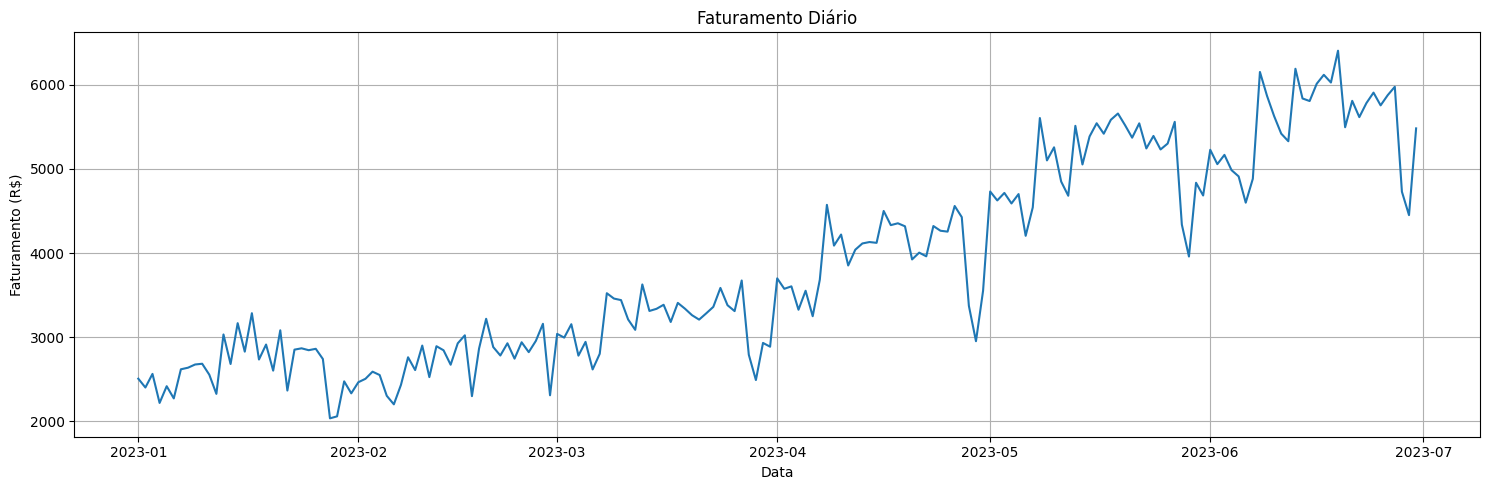

In [ ]:
#Gráfico de faturamento por dia

plt.figure(figsize=(15, 5))
plt.plot(faturamento_por_dia['transaction_date'], faturamento_por_dia['Total_Bill'])
plt.title("Faturamento Diário")
plt.xlabel("Data")
plt.ylabel("Faturamento (R$)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Agrupar o faturamento por mes

faturamento_por_mes = df.groupby(df['Month'], as_index=False)['Total_Bill'].sum()

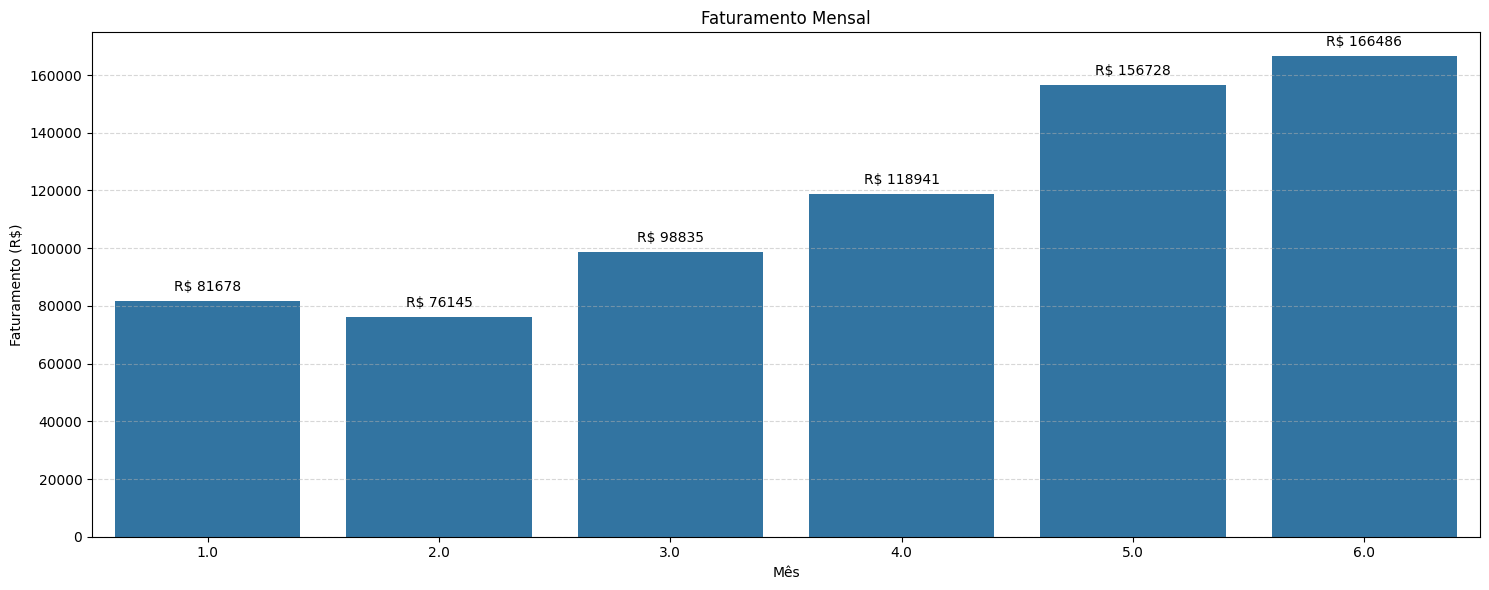

In [ ]:
#Grafico de faturamento por mês

plt.figure(figsize=(15, 6))
ax = sns.barplot(x='Month', y='Total_Bill', data=faturamento_por_mes)
for i in ax.containers:
    ax.bar_label(i, fmt='R$ %.0f', label_type='edge', padding=5, fontsize=10, color='black')
plt.title("Faturamento Mensal")
plt.xlabel("Mês")
plt.ylabel("Faturamento (R$)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Agrupar o faturamento por dia da semana
faturamento_por_dia_semana = df.groupby(df['Day Name'], as_index=False)['Total_Bill'].sum()

In [ ]:
# Definindo a ordem correta dos dias da semana
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Transformando a coluna em categórica ordenada
faturamento_por_dia_semana['Day Name'] = pd.Categorical(faturamento_por_dia_semana['Day Name'], categories=ordem_dias, ordered=True)

# Ordenando o DataFrame
faturamento_dia = faturamento_por_dia_semana.sort_values('Day Name')


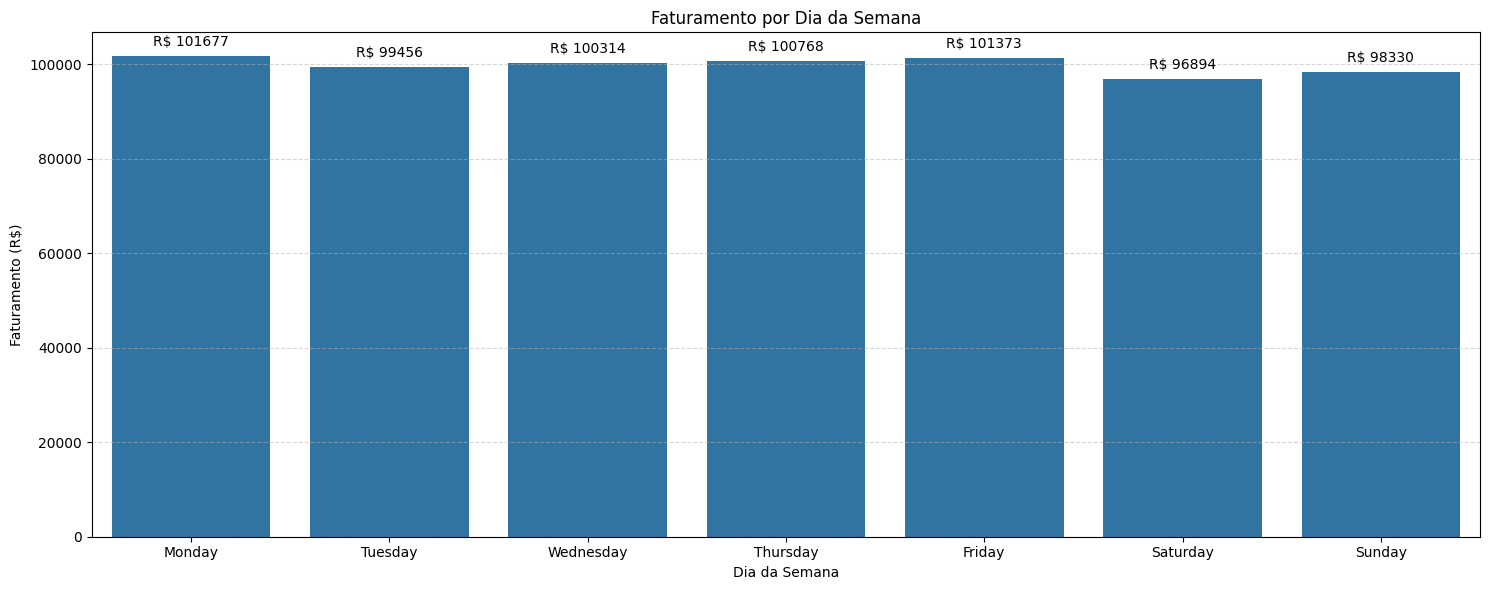

In [ ]:
# Faturamento por dia da semana

plt.figure(figsize=(15, 6))
ax = sns.barplot(x='Day Name', y='Total_Bill', data=faturamento_dia)
for i in ax.containers:
    ax.bar_label(i, fmt='R$ %.0f', label_type='edge', padding=5, fontsize=10, color='black')
plt.title("Faturamento por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Faturamento (R$)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
#Criando a coluna Intervalo de Hora

df['intervalo_hora'] = df['Hour'].astype(int).astype(str) + '-' + (df['Hour'] + 1).astype(int).astype(str)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149116 entries, 0 to 149115
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  float64       
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  datetime64[ns]
 3   store_id          149116 non-null  float64       
 4   store_location    149116 non-null  object        
 5   product_id        149116 non-null  float64       
 6   transaction_qty   149116 non-null  float64       
 7   unit_price        149116 non-null  float64       
 8   Total_Bill        149116 non-null  float64       
 9   product_category  149116 non-null  object        
 10  product_type      149116 non-null  object        
 11  product_detail    149116 non-null  object        
 12  Size              149116 non-null  object        
 13  Month Name        149116 non-null  object        
 14  Day Name 

In [ ]:
# Agrupando o faturamento pelo Intervalo de Hora

faturamento_por_hora = df.groupby('intervalo_hora')['Total_Bill'].sum().reset_index()

In [ ]:
# Extrair somente a Hora para criar os intervalos

faturamento_por_hora['hora_inicio'] = (
    faturamento_por_hora['intervalo_hora']
    .str.extract(r'(\d+)-')[0]   # pega o número antes do "-"
    .astype(float)               # usar float primeiro
    .fillna(-1)                  # só por segurança
    .astype(int)
)


In [ ]:
# Ordenar os intervalos

faturamento_por_hora = faturamento_por_hora.sort_values('hora_inicio')

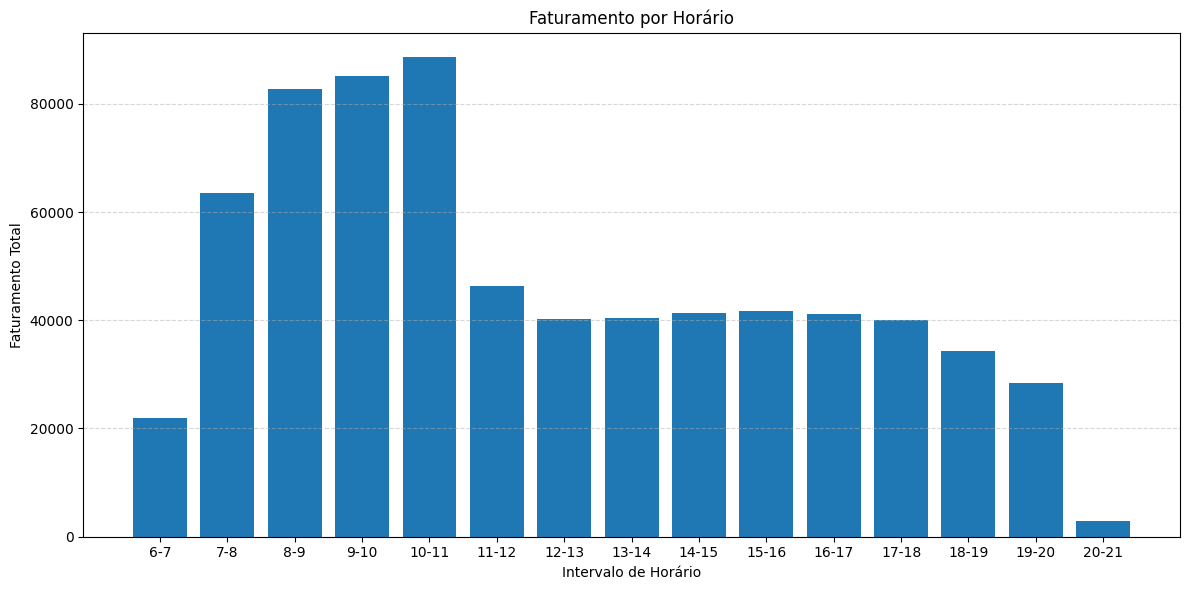

In [ ]:
# Grafico de faturamento por horário

plt.figure(figsize=(12, 6))
plt.bar(faturamento_por_hora['intervalo_hora'], faturamento_por_hora['Total_Bill'])

plt.title('Faturamento por Horário')
plt.xlabel('Intervalo de Horário')
plt.ylabel('Faturamento Total')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
#Agrupar o faturamento por loja

faturamento_loja = df.groupby('store_location', as_index=False)['Total_Bill'].sum()

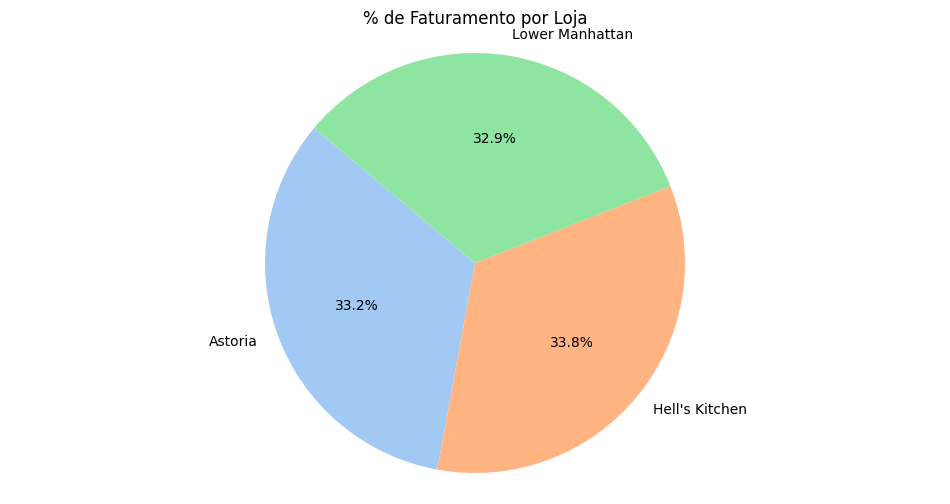

In [ ]:
# Grafico faturamento por loja

plt.figure(figsize=(12, 6))
plt.pie(faturamento_loja['Total_Bill'], labels=faturamento_loja['store_location'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('% de Faturamento por Loja')
plt.axis('equal')
plt.show()

In [ ]:
#Agrupar o faturamento por Categoria de Produto

faturamento_categoria = df.groupby('product_category', as_index=False)['Total_Bill'].sum()

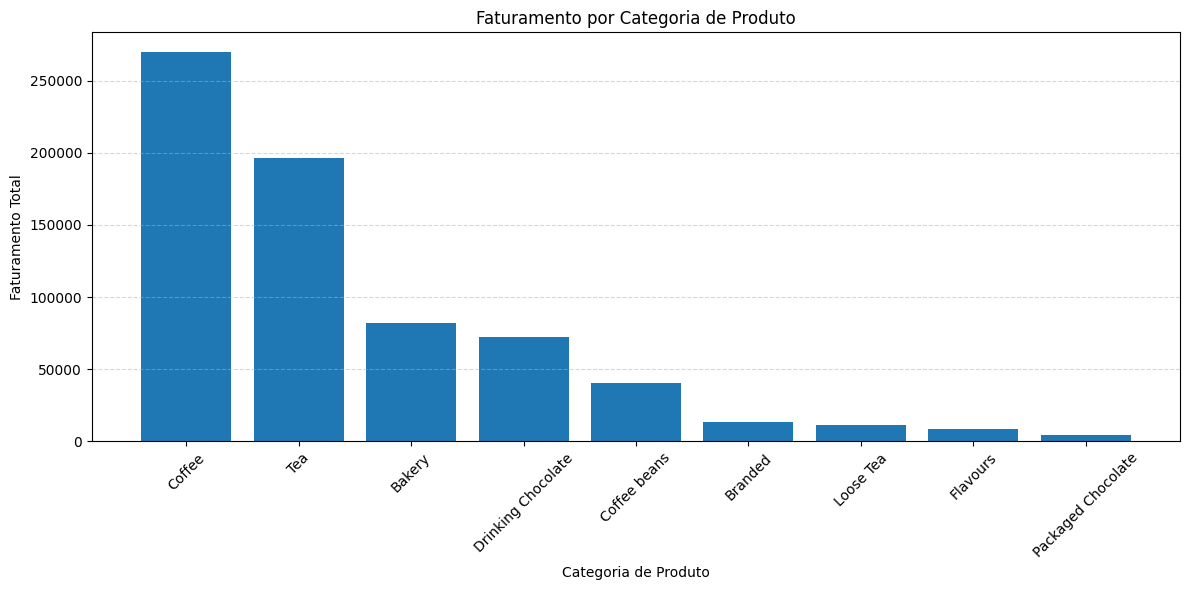

In [ ]:
#Grafico Faturamento por categoria de produto

faturamento_categoria_ordenado = faturamento_categoria.sort_values(by='Total_Bill', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(faturamento_categoria_ordenado['product_category'], faturamento_categoria_ordenado['Total_Bill'])
plt.title('Faturamento por Categoria de Produto')
plt.xlabel('Categoria de Produto')
plt.ylabel('Faturamento Total')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Agrupar o faturamento por Categoria de Produto

faturamento_tipo = df.groupby('product_type', as_index=False)['Total_Bill'].sum()

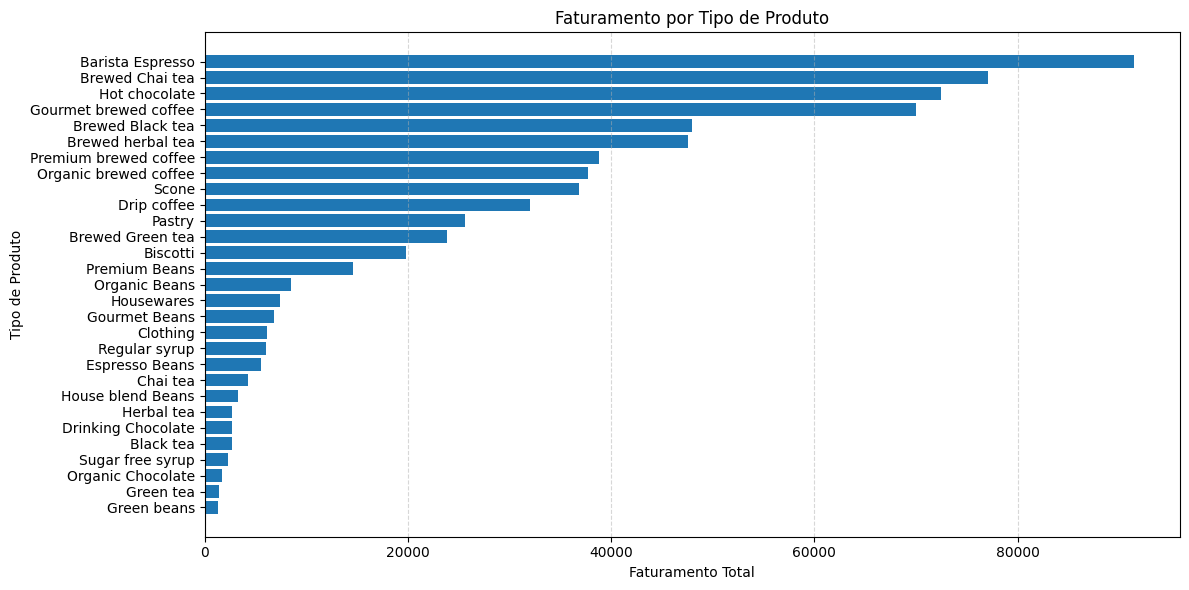

In [ ]:
# Grafico faturamento por tipo de produto

faturamento_tipo_ordenado = faturamento_tipo.sort_values(by='Total_Bill', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(faturamento_tipo_ordenado['product_type'], faturamento_tipo_ordenado['Total_Bill'])
plt.title('Faturamento por Tipo de Produto')
plt.xlabel('Faturamento Total')
plt.ylabel('Tipo de Produto')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Análise Diagnóstica
**Verificando a correlação entre as variáveis**

In [ ]:
# Gráfico Cascata GR% Faturamento

import plotly.graph_objects as go

# Agrupando por mês
df_mensal = df.groupby(['Month', 'Month Name'])['Total_Bill'].sum().reset_index()

# Ordenar pelos meses corretamente
df_mensal = df_mensal.sort_values('Month')

# Calcular a variação percentual
df_mensal['GR_Percent'] = df_mensal['Total_Bill'].pct_change() * 100

# O primeiro mês virá como NaN, vamos preencher com 0
df_mensal['GR_Percent'] = df_mensal['GR_Percent'].fillna(0)

# 3. Criar Gráfico
fig = go.Figure(go.Waterfall(
    name = "Crescimento",
    orientation = "v",
    measure = ["relative"] * len(df_mensal), # Todos são relativos ao anterior
    x = df_mensal['Month Name'],
    y = df_mensal['GR_Percent'],
    text = df_mensal['GR_Percent'].apply(lambda x: f"{x:.1f}%"), # Rótulo de texto
    textposition = "outside",
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
    increasing = {"marker":{"color": "#2c6381"}}, # Azul do seu print
    decreasing = {"marker":{"color": "#ef7d31"}}, # Laranja do seu print
))

fig.update_layout(
    title = "GR% Faturamento",
    showlegend = False,
    plot_bgcolor = 'white',
    yaxis_ticksuffix = "%"
)

fig.show()

In [ ]:

from plotly.subplots import make_subplots

# 1. Agrupamento por Loja e Mês
# Somamos o faturamento agrupando por localização e o número do mês
df_lojas = df.groupby(['store_location', 'Month', 'Month Name'])['Total_Bill'].sum().reset_index()
df_lojas = df_lojas.sort_values(['store_location', 'Month'])

# 2. Cálculo do GR% por Loja
# Usamos groupby antes do pct_change para que o cálculo de uma loja não "atropele" a outra
df_lojas['GR_Percent'] = df_lojas.groupby('store_location')['Total_Bill'].pct_change() * 100
df_lojas['GR_Percent'] = df_lojas['GR_Percent'].fillna(0)

# 3. Configuração dos Subplots
lojas = df_lojas['store_location'].unique()
fig = make_subplots(rows=len(lojas), cols=1,
                    subplot_titles=[f"Loja: {l}" for l in lojas],
                    vertical_spacing=0.1)

# 4. Adicionando cada loja ao gráfico
for i, loja in enumerate(lojas):
    dados_loja = df_lojas[df_lojas['store_location'] == loja]

    fig.add_trace(
        go.Waterfall(
            x = dados_loja['Month Name'],
            y = dados_loja['GR_Percent'],
            text = dados_loja['GR_Percent'].apply(lambda x: f"{x:.1f}%"),
            textposition = "outside",
            increasing = {"marker":{"color": "#2c6381"}},
            decreasing = {"marker":{"color": "#ef7d31"}},
            connector = {"line":{"color":"#ccc"}},
        ),
        row=i+1, col=1
    )

# 5. Ajustes de Layout
fig.update_layout(
    title_text="Crescimento de Faturamento (GR%) por Unidade",
    height=300 * len(lojas), # Ajusta a altura conforme o número de lojas
    showlegend=False,
    plot_bgcolor='white'
)

fig.show()

In [ ]:
# Gráfico crescimento da quantida de itens vendidos

# 1. Consolidando os dados por Mês (Soma de todas as lojas)
df_geral = df.groupby(['Month', 'Month Name'])['transaction_qty'].sum().reset_index()
df_geral = df_geral.sort_values('Month')

# 2. Calculando o Growth Rate % Geral
# (Valor Atual - Valor Anterior) / Valor Anterior
df_geral['Qty_Growth_%'] = df_geral['transaction_qty'].pct_change() * 100
df_geral['Qty_Growth_%'] = df_geral['Qty_Growth_%'].fillna(0)

# 3. Criando o Gráfico de Cascata Geral
fig = go.Figure(go.Waterfall(
    name = "Crescimento Geral",
    orientation = "v",
    measure = ["relative"] * len(df_geral),
    x = df_geral['Month Name'],
    y = df_geral['Qty_Growth_%'],
    text = df_geral['Qty_Growth_%'].apply(lambda x: f"{x:.1f}%"),
    textposition = "outside",
    # Estilização visual (Azul para subida, Laranja para descida)
    increasing = {"marker":{"color": "#2c6381"}},
    decreasing = {"marker":{"color": "#ef7d31"}},
    connector = {"line":{"color":"#d3d3d3", "width": 1.5, "dash": "dot"}},
))

# 4. Ajustes de Layout e Títulos
fig.update_layout(
    title = {
        'text': "<b>Crescimento Percentual de Itens Vendidos (Geral)</b>",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'
    },
    yaxis_title = "Variação %",
    yaxis_ticksuffix = "%",
    plot_bgcolor = 'white',
    height = 500
)

# Adicionando uma linha de referência no zero
fig.add_hline(y=0, line_dash="solid", line_color="black", line_width=1)

fig.show()

In [ ]:
#Crescimento do preço médio

# 1. Agrupamento mensal somando Faturamento e Quantidade
df_preco = df.groupby(['Month', 'Month Name']).agg({
    'Total_Bill': 'sum',
    'transaction_qty': 'sum'
}).reset_index()

# 2. Calcular o Preço Médio por mês
df_preco['Avg_Price'] = df_preco['Total_Bill'] / df_preco['transaction_qty']

# 3. Calcular a variação percentual do Preço Médio
df_preco['Price_Growth_%'] = df_preco['Avg_Price'].pct_change() * 100
df_preco['Price_Growth_%'] = df_preco['Price_Growth_%'].fillna(0)

# 4. Criar o Gráfico de Cascata
fig = go.Figure(go.Waterfall(
    name = "Evolução Preço Médio",
    orientation = "v",
    measure = ["relative"] * len(df_preco),
    x = df_preco['Month Name'],
    y = df_preco['Price_Growth_%'],
    text = df_preco['Price_Growth_%'].apply(lambda x: f"{x:.1f}%"),
    textposition = "outside",
    increasing = {"marker":{"color": "#2c6381"}},
    decreasing = {"marker":{"color": "#ef7d31"}},
    connector = {"line":{"color":"#d3d3d3", "width": 1.5}},
))

# 5. Ajustes de Layout
fig.update_layout(
    title = "<b>Crescimento Percentual do Preço Médio por Item</b>",
    yaxis_title = "Variação %",
    yaxis_ticksuffix = "%",
    plot_bgcolor = 'white',
    height = 500
)

fig.show()

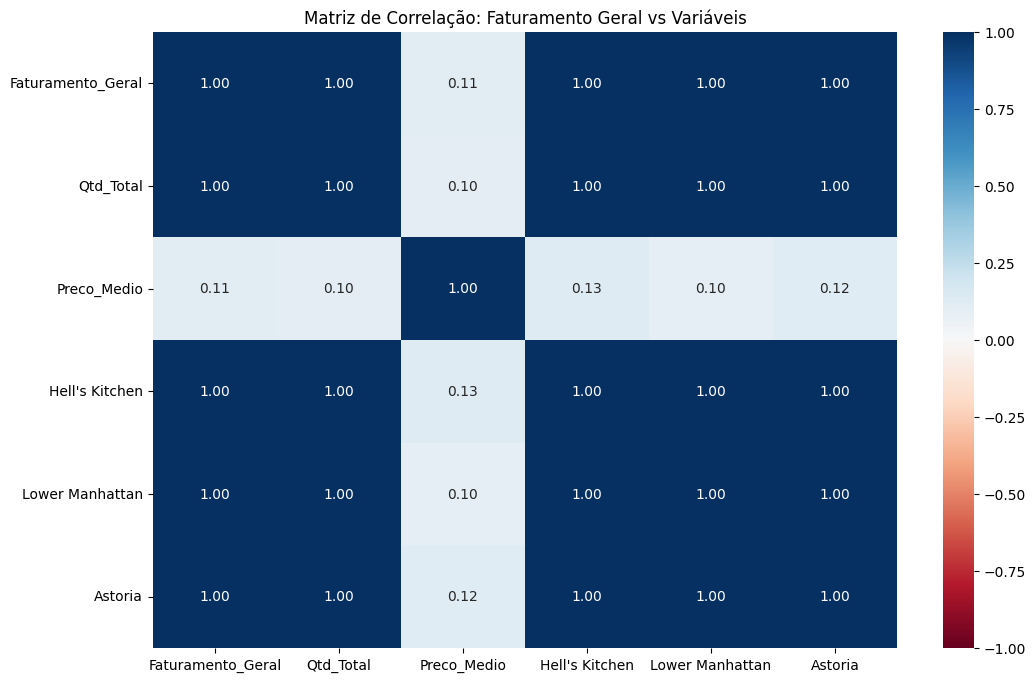

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparando as métricas gerais por mês
df_mensal = df.groupby(['Month', 'Month Name']).agg({
    'Total_Bill': 'sum',
    'transaction_qty': 'sum'
}).reset_index()

# Cálculo do Preço Médio Geral
df_mensal['Preco_Medio'] = df_mensal['Total_Bill'] / df_mensal['transaction_qty']
df_mensal.rename(columns={'Total_Bill': 'Faturamento_Geral', 'transaction_qty': 'Qtd_Total'}, inplace=True)

# 2. Preparando o faturamento individual por loja (Pivot Table)
df_lojas_pivot = df.pivot_table(
    index=['Month', 'Month Name'],
    columns='store_location',
    values='Total_Bill',
    aggfunc='sum'
).reset_index()

# 3. Cruzando tudo em um único DataFrame de Correlação
df_corr = pd.merge(df_mensal, df_lojas_pivot, on=['Month', 'Month Name'])

# Selecionar apenas as colunas numéricas para a matriz
# Removemos 'Month' e 'Month Name' para não poluir o cálculo
colunas_analise = ['Faturamento_Geral', 'Qtd_Total', 'Preco_Medio'] + list(df['store_location'].unique())
matriz_correlacao = df_corr[colunas_analise].corr()

# 4. Plotando o Heatmap (Mapa de Calor)
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlação: Faturamento Geral vs Variáveis')
plt.show()

## Análise Preditiva

**Prever o faturamento dos próximos 30 dias**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from datetime import timedelta
import numpy as np

In [ ]:
# Converter coluna de data
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [ ]:
# Agragar o faturamento por dia
faturamento_diario = df.groupby('transaction_date')['Total_Bill'].sum().reset_index()

In [ ]:
# Criar variável numérica para regressão
faturamento_diario['dia_num'] = (faturamento_diario['transaction_date'] - faturamento_diario['transaction_date'].min()).dt.days


In [ ]:
# Dividir variáveis
X = faturamento_diario[['dia_num']]
y = faturamento_diario['Total_Bill']

In [ ]:
# Treinar modelo
modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [ ]:
# Previsão para os próximos 30 dias
dias_futuros = np.arange(X['dia_num'].max() + 1, X['dia_num'].max() + 31).reshape(-1, 1)
datas_futuras = [faturamento_diario['transaction_date'].max() + timedelta(days=i) for i in range(1, 31)]
previsoes = modelo.predict(dias_futuros)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


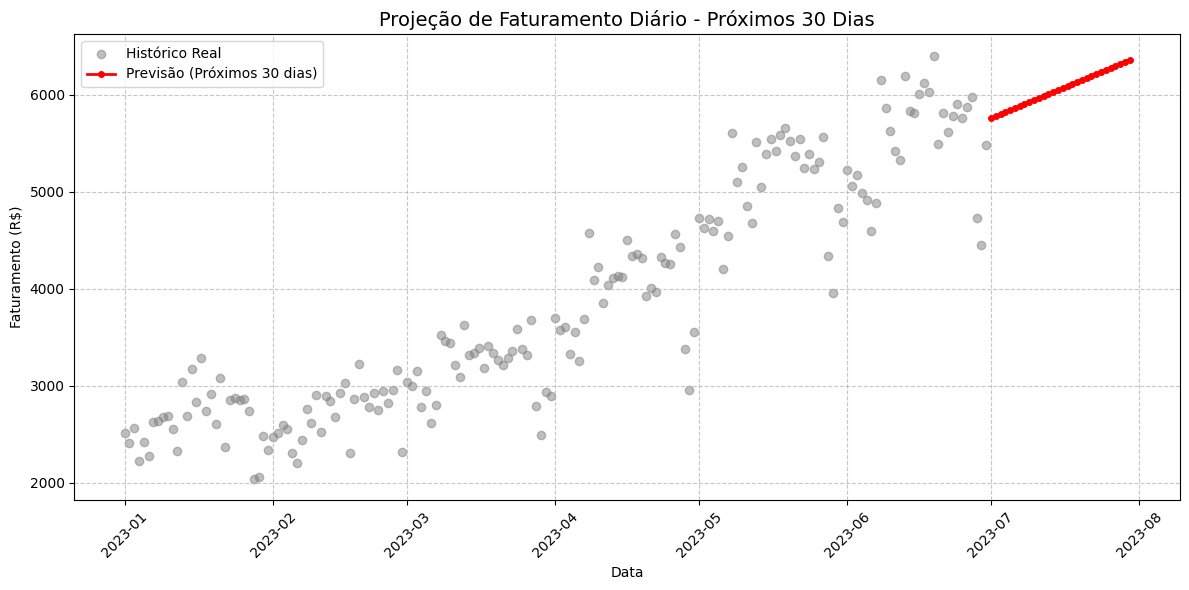

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(faturamento_diario['transaction_date'], faturamento_diario['Total_Bill'], color='gray', alpha=0.5, label='Histórico Real')
plt.plot(datas_futuras, previsoes, color='red', linewidth=2, marker='o', markersize=4, label='Previsão (Próximos 30 dias)')
plt.title('Projeção de Faturamento Diário - Próximos 30 Dias', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Faturamento (R$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Métricas do Modelo**

In [ ]:
#MAPE

from sklearn.metrics import mean_absolute_percentage_error

# Previsão sobre os dados históricos
y_pred = modelo.predict(X)
y_real = y.values  # ou faturamento_diario['Total_Bill']

# Calcular MAPE
mape = mean_absolute_percentage_error(y_real, y_pred) * 100
print(f'MAPE: {mape:.2f}%')


MAPE: 10.39%


In [ ]:
#RMSE

from sklearn.metrics import mean_squared_error
import numpy as np

# Calcular RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f'RMSE: {rmse:.2f}')


RMSE: 466.16
